In [230]:
def run_fused_attention_model(
    sms_embeddings,
    call_embeddings,
    proximity_embeddings,
    labels,
    model_name,
    max_epochs=150,
    patience=15,
):
    all_indices = np.arange(len(labels))
    train_indices, val_indices = train_test_split(
        all_indices,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=labels,
    )

    sms_train = torch.from_numpy(sms_embeddings[train_indices])
    calls_train = torch.from_numpy(call_embeddings[train_indices])
    proximity_train = torch.from_numpy(proximity_embeddings[train_indices])
    y_train = torch.from_numpy(labels[train_indices]).view(-1, 1)
    sms_val = torch.from_numpy(sms_embeddings[val_indices])
    calls_val = torch.from_numpy(call_embeddings[val_indices])
    proximity_val = torch.from_numpy(proximity_embeddings[val_indices])
    y_val = torch.from_numpy(labels[val_indices]).view(-1, 1)

    train_weights, minority_class, minority_weight = minority_sample_weights(
        labels[train_indices]
    )
    val_weights, _, _ = minority_sample_weights(
        labels[val_indices], minority_class, minority_weight
    )
    train_weight_tensor = torch.from_numpy(train_weights).view(-1, 1)
    val_weight_tensor = torch.from_numpy(val_weights).view(-1, 1)

    train_loader = DataLoader(
        TensorDataset(
            sms_train,
            calls_train,
            proximity_train,
            y_train,
            train_weight_tensor,
        ),
        batch_size=32,
        shuffle=True,
    )

    torch.manual_seed(RANDOM_STATE)
    fused_model = FusedNetwork(embedding_dim=sms_embeddings.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    optimizer = torch.optim.Adam(
        fused_model.parameters(), lr=1e-3, weight_decay=1e-4
    )
    print(
        f'{model_name}: upweighting class {int(minority_class)} '
        f'by {minority_weight:.2f}x; no rows removed.'
    )

    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0
    train_losses = []
    val_losses = []

    with tqdm(
        range(max_epochs), desc=model_name, unit='epoch'
    ) as epoch_progress:
        for epoch in epoch_progress:
            fused_model.train()
            running_loss = 0.0
            for sms_batch, calls_batch, proximity_batch, y_batch, weight_batch in train_loader:
                optimizer.zero_grad()
                logits = fused_model(sms_batch, calls_batch, proximity_batch)
                element_losses = criterion(logits, y_batch)
                loss = (element_losses * weight_batch).mean()
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * y_batch.size(0)

            train_loss = running_loss / len(train_loader.dataset)
            train_losses.append(train_loss)
            fused_model.eval()
            with torch.no_grad():
                val_logits = fused_model(sms_val, calls_val, proximity_val)
                val_element_losses = criterion(val_logits, y_val)
                val_loss = (
                    val_element_losses * val_weight_tensor
                ).mean().item()
            val_losses.append(val_loss)
            epoch_progress.set_postfix(
                train_loss=f'{train_loss:.4f}',
                val_loss=f'{val_loss:.4f}',
                best=f'{min(best_val_loss, val_loss):.4f}',
            )

            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                best_state = copy.deepcopy(fused_model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    epoch_progress.set_description(f'{model_name} (early stopped)')
                    break

    fused_model.load_state_dict(best_state)
    fused_model.eval()
    with torch.no_grad():
        val_logits, attention = fused_model(
            sms_val, calls_val, proximity_val, return_weights=True
        )
        probabilities = torch.sigmoid(val_logits.squeeze(1)).numpy()

    y_true = y_val.squeeze(1).numpy().astype(int)
    predictions = (probabilities >= 0.5).astype(int)
    metrics = metric_row(
        y_true, predictions, probabilities, model_name
    )
    attention_summary = pd.DataFrame(
        {
            'Model': model_name,
            'Channel': ['SMS', 'Calls', 'Proximity'],
            'Mean attention weight': attention.mean(dim=0).numpy(),
        }
    )
    history = {'train_loss': train_losses, 'val_loss': val_losses}
    return fused_model, metrics, attention_summary, history


In [231]:
import networkx as nx
import pandas as pd
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from tqdm.auto import tqdm
import great_tables
print('setup complete')

setup complete


In [232]:
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(1)
np.random.seed(100)


In [233]:
fb_friends_data = pd.read_csv("../data/interim/fb_friends.csv")
display(fb_friends_data)

friends_list = list(zip(fb_friends_data["user_a"], fb_friends_data["user_b"]))
print(friends_list)

friends_set = set(friends_list)

,Unnamed: 0,user_a,user_b
0,0,0,512
1,1,0,263
2,2,0,525
3,3,0,285
4,4,0,543
...,...,...,...
6413,6424,510,737
6414,6425,510,763
6415,6426,255,566
6416,6427,255,605


[(0, 512), (0, 263), (0, 525), (0, 285), (0, 543), (0, 806), (0, 817), (0, 824), (0, 341), (0, 600), (0, 104), (0, 107), (0, 108), (0, 371), (0, 632), (0, 687), (0, 208), (0, 744), (0, 491), (256, 524), (256, 532), (256, 818), (256, 838), (256, 373), (256, 421), (256, 706), (256, 486), (512, 790), (512, 538), (512, 809), (512, 560), (512, 820), (512, 580), (512, 839), (512, 631), (512, 690), (512, 700), (512, 728), (768, 838), (1, 537), (1, 43), (1, 345), (1, 390), (1, 412), (1, 420), (257, 514), (257, 534), (257, 545), (257, 816), (257, 565), (257, 574), (257, 578), (257, 331), (257, 346), (257, 359), (257, 621), (257, 659), (257, 444), (257, 707), (257, 721), (513, 519), (513, 544), (513, 590), (513, 653), (513, 663), (2, 817), (2, 354), (2, 140), (2, 666), (2, 686), (2, 720), (2, 502), (258, 775), (258, 532), (258, 792), (258, 302), (258, 561), (258, 590), (514, 534), (514, 578), (514, 659), (514, 679), (514, 721), (770, 824), (3, 521), (3, 23), (3, 49), (3, 817), (3, 90), (3, 357),

# SMS graph

In [234]:
sms_data = pd.read_csv('../data/interim/sms.csv', index_col=0)
sms_data = sms_data.astype({'sender': 'int', 'recipient': 'int'})

# Facebook friendship is undirected, so represent each relationship once.
sms_data['user_a'] = sms_data[['sender', 'recipient']].min(axis=1)
sms_data['user_b'] = sms_data[['sender', 'recipient']].max(axis=1)

sms_relationships = (
    sms_data.groupby(['user_a', 'user_b'])
    .size()
    .rename('total_texts')
    .reset_index()
)

display(sms_relationships.head())
print(f"Raw SMS records: {len(sms_data):,}")
print(f"Unique SMS relationships: {len(sms_relationships):,}")

,user_a,user_b,total_texts
0,0,208,4
1,0,512,132
2,1,345,3
3,3,49,75
4,3,217,6


Raw SMS records: 24,333
Unique SMS relationships: 697


Text(0.5, 0, 'pairs')

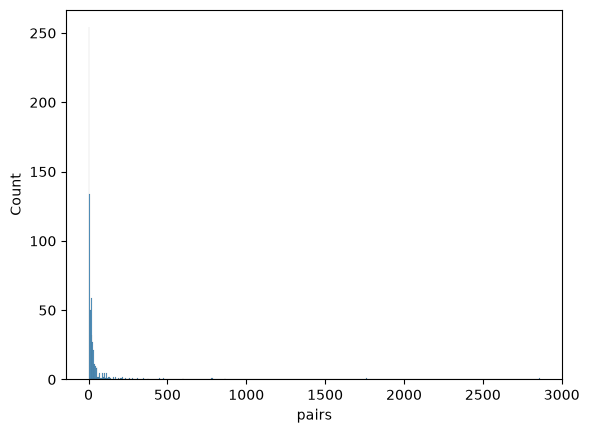

In [235]:
sns.histplot(x=sms_relationships['total_texts'])
plt.xlabel('pairs')

In [236]:
sms_relationships["node2vec_weight"] = np.log1p(sms_relationships["total_texts"])
sms_relationships.head()


,user_a,user_b,total_texts,node2vec_weight
0,0,208,4,1.609438
1,0,512,132,4.890349
2,1,345,3,1.386294
3,3,49,75,4.330733
4,3,217,6,1.945910


In [237]:
G_sms = nx.Graph()

for row in sms_relationships.itertuples(index=False):
    G_sms.add_edge(
        int(row.user_a),
        int(row.user_b),
        weight=float(row.node2vec_weight),
        total_texts=float(row.total_texts),
    )

# Keep G as the SMS graph for the Node2Vec code below.
G = G_sms
edges = list(
    sms_relationships[['user_a', 'user_b']]
    .itertuples(index=False, name=None)
)

print(edges[:3])

[(0, 208), (0, 512), (1, 345)]


In [238]:
print(f"SMS graph nodes: {G_sms.number_of_nodes():,}")
print(f"SMS graph relationships: {G_sms.number_of_edges():,}")
print(f"Total texts stored on edges: {sum(nx.get_edge_attributes(G_sms, 'total_texts').values()):,}")

SMS graph nodes: 568
SMS graph relationships: 697
Total texts stored on edges: 24,333.0


In [239]:
sms_node2vec = Node2Vec(
    G_sms,
    dimensions=128,
    walk_length=30,
    num_walks=200,
    workers=1,
    weight_key='weight',
    seed=RANDOM_STATE,
    p=1.0,
    q=2.0
    
)  # tune p and q

sms_node2vec_model = sms_node2vec.fit(window=10, min_count=1)


concat_pairs = []
product_pairs = []  # hadamard product, element-wise interaction
for user_a, user_b in edges:
    u = sms_node2vec_model.wv[str(user_a)]
    v = sms_node2vec_model.wv[str(user_b)]
    label = int((user_a, user_b) in friends_set)

    concat_pairs.append([np.concatenate([u, v]), label])
    product_pairs.append([u * v, label])

print(f"Pair embeddings created: {len(concat_pairs):,}")

Computing transition probabilities:   0%|          | 0/568 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:02<00:00, 71.76it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Pair embeddings created: 697


## Concat MLP

In [240]:
class ConcatMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output_layer(x) # will use BCEWithLogitsLoss, don't need final sigmoid
        return x
    

In [241]:
temp = pd.DataFrame(columns=["embeddings", "is_friends"], data=concat_pairs)
temp.head()

,embeddings,is_friends
0,"[-0.56316495, -0.15060112, -0.14475124, 0.2841...",1
1,"[-0.56316495, -0.15060112, -0.14475124, 0.2841...",1
2,"[-0.093422055, 0.5504156, -0.5931576, -0.59888...",1
3,"[0.057247728, 0.26673532, 0.16202243, 0.188085...",1
4,"[0.057247728, 0.26673532, 0.16202243, 0.188085...",1


In [242]:
X = np.stack(temp["embeddings"].values).astype(np.float32)
y = temp["is_friends"].values.astype(np.float32)


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_tensor = torch.from_numpy(X_train)

y_train_tensor = torch.from_numpy(y_train).view(-1, 1)

X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val).view(-1, 1)

# create the Dataset and DataLoader strictly for the TRAINING split
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [243]:

model = ConcatMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 300

# History
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_state = None

print("Training started...")
print(f"{'=' * 50}\n")

for epoch in range(epochs):
    # ---- Training phase ----
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    # sample-weighted average
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation phase ----
    model.eval()
    with torch.no_grad():
        
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)
        val_losses.append(val_loss.item())
        
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss.item():.4f}"
        )

print(f"\n{'=' * 50}")
print("Training completed!")
print(f"Best val loss: {best_val_loss:.4f}")
model.load_state_dict(best_state)

Training started...

Epoch  20, Train Loss: 0.1168, Val Loss: 0.9732
Epoch  40, Train Loss: 0.0329, Val Loss: 1.4455
Epoch  60, Train Loss: 0.0331, Val Loss: 1.6260
Epoch  80, Train Loss: 0.0176, Val Loss: 1.5772
Epoch 100, Train Loss: 0.0219, Val Loss: 1.6701
Epoch 120, Train Loss: 0.0162, Val Loss: 1.6724
Epoch 140, Train Loss: 0.0260, Val Loss: 1.8173
Epoch 160, Train Loss: 0.0088, Val Loss: 1.8893
Epoch 180, Train Loss: 0.0046, Val Loss: 2.0956
Epoch 200, Train Loss: 0.0171, Val Loss: 1.7118
Epoch 220, Train Loss: 0.0031, Val Loss: 1.9285
Epoch 240, Train Loss: 0.0033, Val Loss: 2.0110
Epoch 260, Train Loss: 0.0035, Val Loss: 1.8272
Epoch 280, Train Loss: 0.0029, Val Loss: 1.9982
Epoch 300, Train Loss: 0.0014, Val Loss: 2.1901

Training completed!
Best val loss: 0.4675


<All keys matched successfully>

In [244]:
# Evaluate the trained MLP on the held-out validation split.
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor).squeeze(1)
    val_probabilities = torch.sigmoid(val_logits).cpu().numpy()

y_val_true = y_val_tensor.squeeze(1).cpu().numpy().astype(int)
y_val_pred = (val_probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, zero_division=0)
recall = recall_score(y_val_true, y_val_pred, zero_division=0)
auc_roc = roc_auc_score(y_val_true, val_probabilities)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")


Accuracy:  0.8286
Precision: 0.8286
Recall:    1.0000
AUC-ROC:   0.5453


## Concat XGBoost

In [245]:
'''model = xgb.XGBClassifier(
    n_estimators=1000,  # Number of boosting rounds (trees)
    max_depth=6,  # Maximum tree depth
    learning_rate=0.1,  # Step size shrinkage (eta)
    subsample=0.8,  # Fraction of samples to train each tree
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
predictions = model.predict(X_val)


accuracy = accuracy_score(y_val_true, predictions)
precision = precision_score(y_val_true, predictions, zero_division=0)
recall = recall_score(y_val_true, predictions, zero_division=0)
auc_roc = roc_auc_score(y_val_true, predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
'''

'model = xgb.XGBClassifier(\n    n_estimators=1000,  # Number of boosting rounds (trees)\n    max_depth=6,  # Maximum tree depth\n    learning_rate=0.1,  # Step size shrinkage (eta)\n    subsample=0.8,  # Fraction of samples to train each tree\n    early_stopping_rounds=50,\n    random_state=RANDOM_STATE,\n)\n\nmodel.fit(X_train, y_train)\npredictions = model.predict(X_val)\n\n\naccuracy = accuracy_score(y_val_true, predictions)\nprecision = precision_score(y_val_true, predictions, zero_division=0)\nrecall = recall_score(y_val_true, predictions, zero_division=0)\nauc_roc = roc_auc_score(y_val_true, predictions)\n\nprint(f"Accuracy:  {accuracy:.4f}")\nprint(f"Precision: {precision:.4f}")\nprint(f"Recall:    {recall:.4f}")\nprint(f"AUC-ROC:   {auc_roc:.4f}")\n'

## Hadamard Product MLP

In [246]:
class ProductMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(64,64)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output_layer(x) # will use BCEWithLogitsLoss, don't need final sigmoid
        return x
    

In [247]:
temp = pd.DataFrame(columns=["embeddings", "is_friends"], data=product_pairs)
temp.head()

,embeddings,is_friends
0,"[0.3421231, 0.032978225, 0.05511443, 0.0021077...",1
1,"[0.28948003, -0.00511455, 0.0026740103, 0.0455...",1
2,"[0.0038991321, 0.33137122, 0.34624746, 0.36470...",1
3,"[0.0059002265, 0.03952396, 0.025449533, 0.0104...",1
4,"[0.0057612304, -0.032044332, -0.011255444, 0.0...",1


In [248]:
X = np.stack(temp["embeddings"].values).astype(np.float32)
y = temp["is_friends"].values.astype(np.float32)


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_tensor = torch.from_numpy(X_train)

y_train_tensor = torch.from_numpy(y_train).view(-1, 1)

X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val).view(-1, 1)

# create the Dataset and DataLoader strictly for the TRAINING split
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [249]:

model = ProductMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 300

# History
train_losses = []
val_losses = []
best_val_loss = float("inf")

print("Training started...")
print(f"{'=' * 50}\n")

for epoch in range(epochs):
    # ---- Training phase ----
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    # sample-weighted average
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation phase ----
    model.eval()
    with torch.no_grad():
        # Pass the TENSOR validation data, not the NumPy arrays
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)
        val_losses.append(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            # E.g., torch.save(model.state_dict(), 'best_model.pth')

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss.item():.4f}"
        )

print(f"\n{'=' * 50}")
print("Training completed!")
print(f"Best val loss: {best_val_loss:.4f}")


Training started...

Epoch  20, Train Loss: 0.2254, Val Loss: 0.5974
Epoch  40, Train Loss: 0.1173, Val Loss: 0.9837
Epoch  60, Train Loss: 0.0583, Val Loss: 1.2192
Epoch  80, Train Loss: 0.0443, Val Loss: 1.4825
Epoch 100, Train Loss: 0.0318, Val Loss: 1.6615
Epoch 120, Train Loss: 0.0214, Val Loss: 1.7843
Epoch 140, Train Loss: 0.0357, Val Loss: 1.8893
Epoch 160, Train Loss: 0.0595, Val Loss: 1.9342
Epoch 180, Train Loss: 0.0086, Val Loss: 2.0966
Epoch 200, Train Loss: 0.0201, Val Loss: 2.1361
Epoch 220, Train Loss: 0.0133, Val Loss: 2.3159
Epoch 240, Train Loss: 0.0051, Val Loss: 2.3108
Epoch 260, Train Loss: 0.0039, Val Loss: 2.3976
Epoch 280, Train Loss: 0.0023, Val Loss: 2.4310
Epoch 300, Train Loss: 0.0018, Val Loss: 2.6052

Training completed!
Best val loss: 0.4600


In [250]:
# Evaluate the trained MLP on the held-out validation split.
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor).squeeze(1)
    val_probabilities = torch.sigmoid(val_logits).cpu().numpy()

y_val_true = y_val_tensor.squeeze(1).cpu().numpy().astype(int)
y_val_pred = (val_probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, zero_division=0)
recall = recall_score(y_val_true, y_val_pred, zero_division=0)
auc_roc = roc_auc_score(y_val_true, val_probabilities)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")


Accuracy:  0.8000
Precision: 0.8438
Recall:    0.9310
AUC-ROC:   0.5454


# Calls Graph

In [251]:
calls_data = pd.read_csv("../data/interim/calls.csv")
display(calls_data.head())

calls_data = calls_data.astype({"caller": "int", "callee": "int"})


,Unnamed: 0,timestamp,caller,callee,duration
0,0,184,300,301,121
1,1,3920,512,299,670
2,2,5623,301,300,504
3,4,15466,512,0,5
4,5,15497,512,0,28


In [252]:
calls_data = pd.read_csv('../data/interim/calls.csv', index_col=0)
calls_data = calls_data.astype({'caller': 'int', 'callee': 'int'})

# Aggregate both call directions into one undirected relationship.
calls_data['user_a'] = calls_data[['caller', 'callee']].min(axis=1)
calls_data['user_b'] = calls_data[['caller', 'callee']].max(axis=1)

call_relationships = (
    calls_data.groupby(['user_a', 'user_b'])
    .agg(
        total_calls=('duration', 'size'),
        total_call_duration=('duration', 'sum'),
    )
    .reset_index()
)

display(call_relationships.head())
print(f"Raw call records: {len(calls_data):,}")
print(f"Unique call relationships: {len(call_relationships):,}")

,user_a,user_b,total_calls,total_call_duration
0,0,208,4,201
1,0,512,5,55
2,3,48,2,39
3,3,49,6,291
4,3,357,7,104


Raw call records: 3,234
Unique call relationships: 605


<Axes: xlabel='total_call_duration', ylabel='Count'>

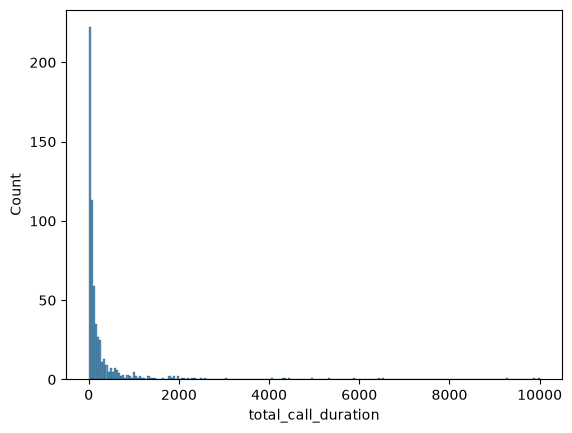

In [253]:
sns.histplot(x=call_relationships['total_call_duration'])

In [254]:
# Zero-duration relationships cannot define weighted Node2Vec transitions.
# Retain them in call_relationships for auditing, but exclude them from G_calls.
call_graph_relationships = call_relationships.loc[
    call_relationships['total_call_duration'].gt(0)
].copy()
call_graph_relationships['node2vec_weight'] = np.log1p(
    call_graph_relationships['total_call_duration']
)

print(f"Zero-duration relationships excluded: {len(call_relationships) - len(call_graph_relationships):,}")
display(call_graph_relationships.head())


Zero-duration relationships excluded: 37


,user_a,user_b,total_calls,total_call_duration,node2vec_weight
0,0,208,4,201,5.308268
1,0,512,5,55,4.025352
2,3,48,2,39,3.688879
3,3,49,6,291,5.676754
4,3,357,7,104,4.653960


In [255]:
G_calls = nx.Graph()

for row in call_graph_relationships.itertuples(index=False):
    G_calls.add_edge(
        int(row.user_a),
        int(row.user_b),
        weight=float(row.node2vec_weight),
        total_call_duration=float(row.total_call_duration),
        total_calls=int(row.total_calls),
    )

print(f"Calls graph nodes: {G_calls.number_of_nodes():,}")
print(f"Calls graph relationships: {G_calls.number_of_edges():,}")
print(f"Total raw duration stored on edges: {sum(nx.get_edge_attributes(G_calls, 'total_call_duration').values()):,.0f}")

Calls graph nodes: 504
Calls graph relationships: 568
Total raw duration stored on edges: 204,813


In [256]:
call_node2vec = Node2Vec(
    G_calls,
    dimensions=128,
    walk_length=30,
    num_walks=200,
    workers=1,
    weight_key="weight",
    p=1.0,
    q=2.0,
    seed=RANDOM_STATE,
)  # tune p and q

call_node2vec_model = call_node2vec.fit(window=10, min_count=1)


call_concat_pairs = []
call_product_pairs = []  # hadamard product, element-wise interaction
call_edges = list(
    call_graph_relationships[['user_a', 'user_b']]
    .itertuples(index=False, name=None)
)

for user_a, user_b in call_edges:
    u = call_node2vec_model.wv[str(user_a)]
    v = call_node2vec_model.wv[str(user_b)]
    label = int((user_a, user_b) in friends_set)

    call_concat_pairs.append([np.concatenate([u, v]), label])
    call_product_pairs.append([u * v, label])

print(f"Call pair embeddings created: {len(call_concat_pairs):,}")


Computing transition probabilities:   0%|          | 0/504 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:02<00:00, 94.27it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Call pair embeddings created: 568


## Shared graph-pair model helpers

These helpers preserve the SMS pipeline structure while using stratified splits, early stopping for the MLP, probability-based ROC AUC, and class balancing when Facebook friendships are the minority.

In [257]:
import copy


class TqdmXGBoostCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds, description):
        self.progress_bar = tqdm(
            total=total_rounds,
            desc=description,
            unit='tree',
        )

    def after_iteration(self, model, epoch, evals_log):
        self.progress_bar.update(1)
        if evals_log:
            dataset = next(iter(evals_log.values()))
            metric_name, metric_values = next(iter(dataset.items()))
            self.progress_bar.set_postfix(
                {metric_name: f'{metric_values[-1]:.4f}'}
            )
        return False

    def after_training(self, model):
        self.progress_bar.close()
        return model


class GraphPairMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)


def pair_records_to_arrays(pair_records):
    X = np.stack([record[0] for record in pair_records]).astype(np.float32)
    y = np.asarray([record[1] for record in pair_records], dtype=np.float32)
    return X, y


def minority_sample_weights(y, minority_class=None, minority_weight=None):
    y = np.asarray(y)
    if minority_class is None or minority_weight is None:
        classes, counts = np.unique(y, return_counts=True)
        if len(classes) != 2:
            raise ValueError('Minority upweighting requires both target classes.')
        minority_position = np.argmin(counts)
        minority_class = classes[minority_position]
        minority_weight = counts.max() / counts.min()
    weights = np.ones(len(y), dtype=np.float32)
    weights[y == minority_class] = minority_weight
    return weights, minority_class, float(minority_weight)


def metric_row(y_true, y_pred, y_probability, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_probability),
    }


def run_pair_mlp(pair_records, model_name, max_epochs=75, patience=8):
    X, y = pair_records_to_arrays(pair_records)
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    X_train_tensor = torch.from_numpy(X_train)
    y_train_tensor = torch.from_numpy(y_train).view(-1, 1)
    X_val_tensor = torch.from_numpy(X_val)
    y_val_tensor = torch.from_numpy(y_val).view(-1, 1)
    train_weights, minority_class, minority_weight = minority_sample_weights(
        y_train
    )
    val_weights, _, _ = minority_sample_weights(
        y_val, minority_class, minority_weight
    )
    train_weight_tensor = torch.from_numpy(train_weights).view(-1, 1)
    val_weight_tensor = torch.from_numpy(val_weights).view(-1, 1)
    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor, train_weight_tensor),
        batch_size=32,
        shuffle=True,
    )


    pair_model = GraphPairMLP(X.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    print(
        f'{model_name}: upweighting class {int(minority_class)} '
        f'by {minority_weight:.2f}x; no rows removed.'
    )
    optimizer = torch.optim.Adam(
        pair_model.parameters(), lr=1e-3, weight_decay=1e-4
    )

    best_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0
    history = []

    with tqdm(
        range(max_epochs), desc=model_name, unit='epoch'
    ) as epoch_progress:
        for epoch in epoch_progress:
            pair_model.train()
            for X_batch, y_batch, weight_batch in train_loader:
                optimizer.zero_grad()
                element_losses = criterion(pair_model(X_batch), y_batch)
                loss = (element_losses * weight_batch).mean()
                loss.backward()
                optimizer.step()

            pair_model.eval()
            with torch.no_grad():
                validation_losses = criterion(
                    pair_model(X_val_tensor), y_val_tensor
                )
                validation_loss = (
                    validation_losses * val_weight_tensor
                ).mean().item()
            history.append(validation_loss)
            epoch_progress.set_postfix(
                val_loss=f'{validation_loss:.4f}',
                best=f'{min(best_loss, validation_loss):.4f}',
            )

            if validation_loss < best_loss - 1e-4:
                best_loss = validation_loss
                best_state = copy.deepcopy(pair_model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    epoch_progress.set_description(
                        f'{model_name} (early stopped)'
                    )
                    break

    pair_model.load_state_dict(best_state)
    pair_model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(
            pair_model(X_val_tensor).squeeze(1)
        ).numpy()
    predictions = (probabilities >= 0.5).astype(int)
    metrics = metric_row(
        y_val.astype(int), predictions, probabilities, model_name
    )
    return pair_model, metrics, history


def run_pair_xgboost(pair_records, model_name):
    X, y = pair_records_to_arrays(pair_records)
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    train_weights, minority_class, minority_weight = minority_sample_weights(
        y_train
    )
    val_weights, _, _ = minority_sample_weights(
        y_val, minority_class, minority_weight
    )
    print(
        f'{model_name}: upweighting class {int(minority_class)} '
        f'by {minority_weight:.2f}x; no rows removed.'
    )
    boosting_rounds = 150
    progress_callback = TqdmXGBoostCallback(
        boosting_rounds, f'{model_name} boosting'
    )
    pair_model = xgb.XGBClassifier(
        n_estimators=boosting_rounds,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
        callbacks=[progress_callback],
    )
    pair_model.fit(
        X_train,
        y_train,
        sample_weight=train_weights,
        eval_set=[(X_val, y_val)],
        sample_weight_eval_set=[val_weights],
        verbose=False,
    )
    probabilities = pair_model.predict_proba(X_val)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    metrics = metric_row(
        y_val.astype(int), predictions, probabilities, model_name
    )
    return pair_model, metrics


## Calls: Concat MLP, Concat XGBoost, and Hadamard MLP

In [258]:
call_concat_mlp, call_concat_mlp_metrics, call_concat_history = run_pair_mlp(
    call_concat_pairs, 'Calls — Concat MLP'
)
call_concat_xgb, call_concat_xgb_metrics = run_pair_xgboost(
    call_concat_pairs, 'Calls — Concat XGBoost'
)
call_product_mlp, call_product_mlp_metrics, call_product_history = run_pair_mlp(
    call_product_pairs, 'Calls — Hadamard MLP'
)

call_product_xgb, call_product_xgb_metrics = run_pair_xgboost(
    call_product_pairs, "Calls — Hadamard XGBoost"
)
call_model_comparison = pd.DataFrame(
    [
        call_concat_mlp_metrics,
        call_concat_xgb_metrics,
        call_product_mlp_metrics,
        call_product_xgb_metrics,
    ]
).set_index("Model")
display(call_model_comparison.round(4))

Calls — Concat MLP: upweighting class 0 by 4.47x; no rows removed.


Calls — Concat MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

Calls — Concat XGBoost: upweighting class 0 by 4.47x; no rows removed.


Calls — Concat XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

Calls — Hadamard MLP: upweighting class 0 by 4.47x; no rows removed.


Calls — Hadamard MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

Calls — Hadamard XGBoost: upweighting class 0 by 4.47x; no rows removed.


Calls — Hadamard XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Calls — Concat MLP,0.7719,0.9351,0.7742,0.8331
Calls — Concat XGBoost,0.8158,0.8830,0.8925,0.7906
Calls — Hadamard MLP,0.7807,0.9359,0.7849,0.8351
Calls — Hadamard XGBoost,0.8860,0.8922,0.9785,0.8428


In [259]:
def compare_performances_viz(df):
    
    for metric in ['Accuracy', 'Precision', 'Recall', 'AUC-ROC']:
        plt.figure(figsize=(9, 4))
        sns.barplot(x=df.index, y=df[metric])
        plt.ylim(0, 1)
        plt.show()

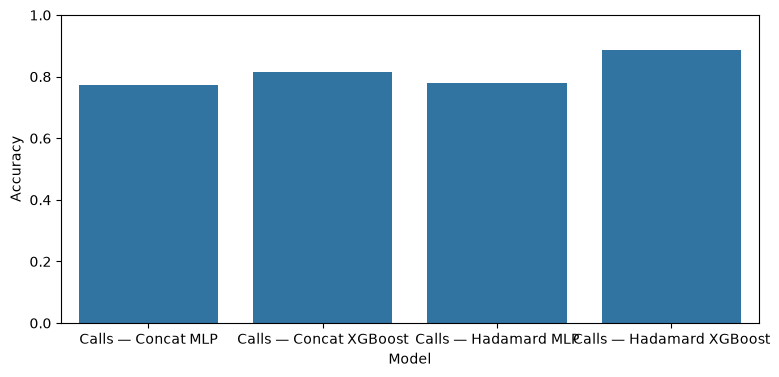

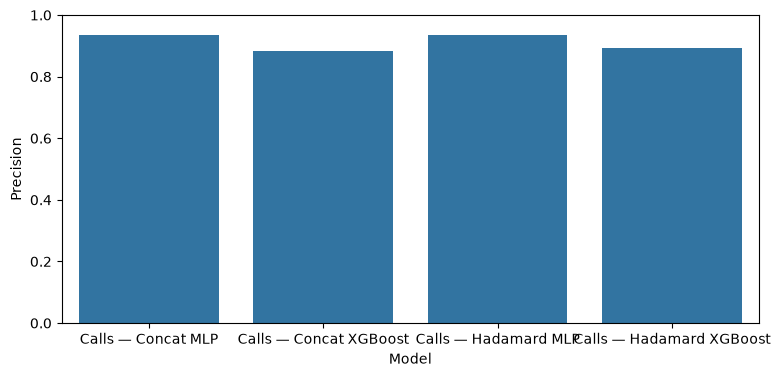

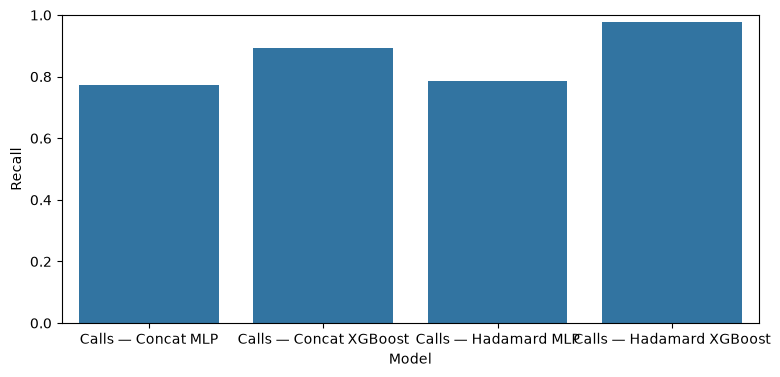

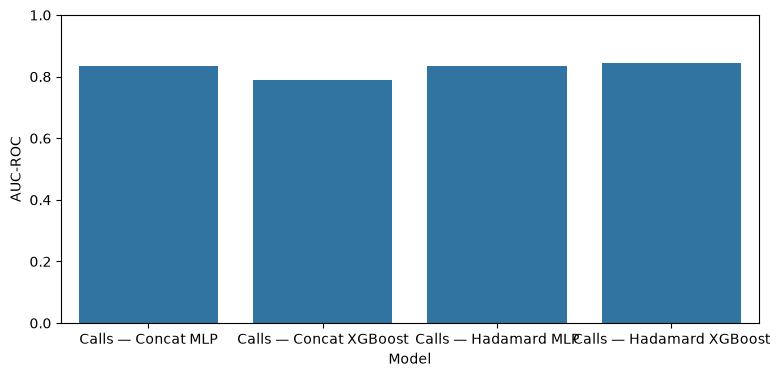

In [260]:
compare_performances_viz(call_model_comparison)

# Proximity Graph

A proximity interaction is a valid participant-to-participant Bluetooth measurement with `rssi > -80`. Each unordered pair appears once, and its edge weight is the total number of qualifying measurements.

In [261]:
RSSI_THRESHOLD = -80
proximity_data = pd.read_csv(
    '../data/raw/bt_symmetric.csv',
    usecols=['# timestamp', 'user_a', 'user_b', 'rssi'],
)

proximity_interactions = proximity_data.loc[
    proximity_data['user_a'].ge(0)
    & proximity_data['user_b'].ge(0)
    & proximity_data['user_a'].ne(proximity_data['user_b'])
    & proximity_data['rssi'].gt(RSSI_THRESHOLD)
].copy()
proximity_interactions['pair_a'] = proximity_interactions[
    ['user_a', 'user_b']
].min(axis=1)
proximity_interactions['pair_b'] = proximity_interactions[
    ['user_a', 'user_b']
].max(axis=1)

proximity_relationships = (
    proximity_interactions.groupby(['pair_a', 'pair_b'])
    .size()
    .rename('total_interactions')
    .reset_index()
    .rename(columns={'pair_a': 'user_a', 'pair_b': 'user_b'})
)

display(proximity_relationships.head())
print(f"Qualifying RSSI measurements: {len(proximity_interactions):,}")
print(f"Unique proximity relationships: {len(proximity_relationships):,}")

,user_a,user_b,total_interactions
0,0,12,9
1,0,25,15
2,0,35,1
3,0,37,19
4,0,52,5


Qualifying RSSI measurements: 659,607
Unique proximity relationships: 31,758


,user_a,user_b,total_interactions
count,31758.000000,31758.000000,31758.000000
mean,220.296650,450.810284,20.769790
std,156.704672,167.738459,97.730301
min,0.000000,5.000000,1.000000
25%,90.000000,325.000000,1.000000
50%,190.000000,473.000000,3.000000
75%,325.000000,586.000000,11.000000
max,704.000000,845.000000,4705.000000


,user_a,user_b,total_interactions
count,31758.000000,31758.000000,31758.000000
mean,220.296650,450.810284,16.593992
std,156.704672,167.738459,41.042415
min,0.000000,5.000000,1.000000
25%,90.000000,325.000000,1.000000
50%,190.000000,473.000000,3.000000
75%,325.000000,586.000000,11.000000
max,704.000000,845.000000,279.000000


<Axes: xlabel='total_interactions', ylabel='Count'>

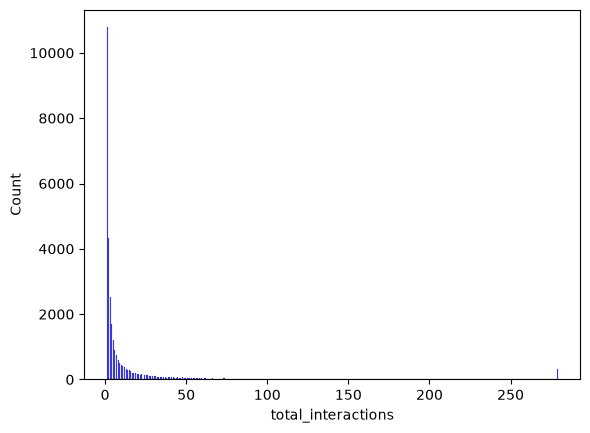

In [262]:
display(proximity_relationships.describe())
proximity_relationships["total_interactions"] = proximity_relationships[
    "total_interactions"
].clip(upper=proximity_relationships['total_interactions'].quantile(0.99))
display(proximity_relationships.describe())
sns.histplot(x=proximity_relationships["total_interactions"], color='blue', edgecolor="black")

In [263]:
proximity_relationships["node2vec_weight"] = np.log1p(
    proximity_relationships["total_interactions"]
)


In [264]:
G_proximity = nx.Graph()
for row in proximity_relationships.itertuples(index=False):
    G_proximity.add_edge(
        int(row.user_a),
        int(row.user_b),
        weight=float(row.node2vec_weight),
        total_interactions=int(row.total_interactions),
    )

proximity_edges = list(
    proximity_relationships[['user_a', 'user_b']]
    .itertuples(index=False, name=None)
)
print(f"Proximity graph nodes: {G_proximity.number_of_nodes():,}")
print(f"Proximity graph relationships: {G_proximity.number_of_edges():,}")
print(f"Total interactions stored on edges: {sum(nx.get_edge_attributes(G_proximity, 'total_interactions').values()):,}")

Proximity graph nodes: 675
Proximity graph relationships: 31,758
Total interactions stored on edges: 526,992


In [265]:
proximity_node2vec = Node2Vec(
    G_proximity,
    dimensions=128,
    walk_length=30,
    num_walks=100,
    workers=1,
    weight_key='weight',
    p=1.0,
    q=2.0,
    seed=RANDOM_STATE,
)
proximity_node2vec_model = proximity_node2vec.fit(
    window=10, min_count=1, seed=RANDOM_STATE
)

proximity_concat_pairs = []
proximity_product_pairs = []
for user_a, user_b in proximity_edges:
    u = proximity_node2vec_model.wv[str(user_a)]
    v = proximity_node2vec_model.wv[str(user_b)]
    label = int((user_a, user_b) in friends_set)
    proximity_concat_pairs.append([np.concatenate([u, v]), label])
    proximity_product_pairs.append([u * v, label])

print(f"Proximity pair embeddings created: {len(proximity_concat_pairs):,}")

Computing transition probabilities:   0%|          | 0/675 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:09<00:00, 10.37it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.

Proximity pair embeddings created: 31,758


## Proximity: Concat MLP, Concat XGBoost, and Hadamard MLP

In [266]:
proximity_concat_mlp, proximity_concat_mlp_metrics, proximity_concat_history = run_pair_mlp(
    proximity_concat_pairs, 'Proximity — Concat MLP'
)
proximity_concat_xgb, proximity_concat_xgb_metrics = run_pair_xgboost(
    proximity_concat_pairs, 'Proximity — Concat XGBoost'
)
proximity_product_mlp, proximity_product_mlp_metrics, proximity_product_history = run_pair_mlp(
    proximity_product_pairs, 'Proximity — Hadamard MLP'
)
proximity_product_xgb, proximity_product_xgb_metrics = run_pair_xgboost(
    proximity_product_pairs, "Proximity — Hadamard XGBoost"
)

proximity_model_comparison = pd.DataFrame(
    [
        proximity_concat_mlp_metrics,
        proximity_concat_xgb_metrics,
        proximity_product_mlp_metrics,
        proximity_product_xgb_metrics,
    ]
).set_index("Model")
display(proximity_model_comparison.round(4))

Proximity — Concat MLP: upweighting class 1 by 11.25x; no rows removed.


Proximity — Concat MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

Proximity — Concat XGBoost: upweighting class 1 by 11.25x; no rows removed.


Proximity — Concat XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

Proximity — Hadamard MLP: upweighting class 1 by 11.25x; no rows removed.


Proximity — Hadamard MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

Proximity — Hadamard XGBoost: upweighting class 1 by 11.25x; no rows removed.


Proximity — Hadamard XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Proximity — Concat MLP,0.8160,0.2610,0.6840,0.8393
Proximity — Concat XGBoost,0.7813,0.2065,0.5896,0.7666
Proximity — Hadamard MLP,0.8007,0.2429,0.6802,0.8209
Proximity — Hadamard XGBoost,0.8158,0.2528,0.6416,0.8180


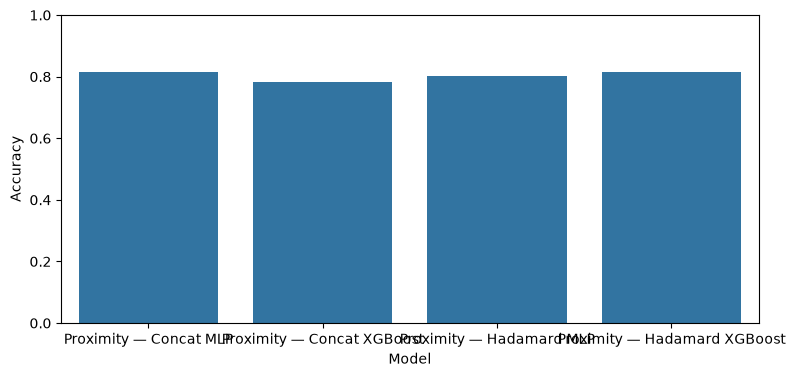

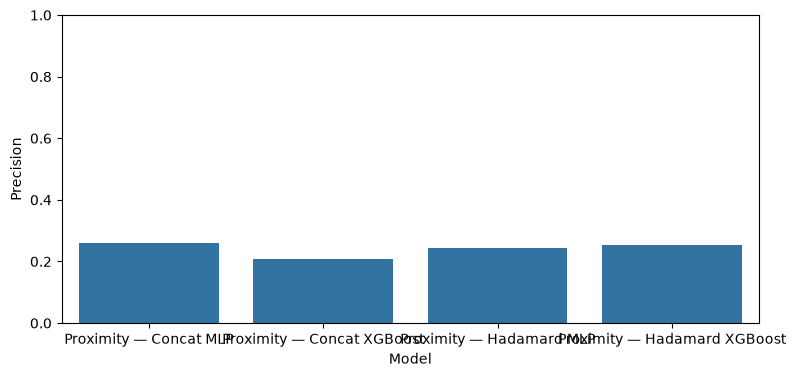

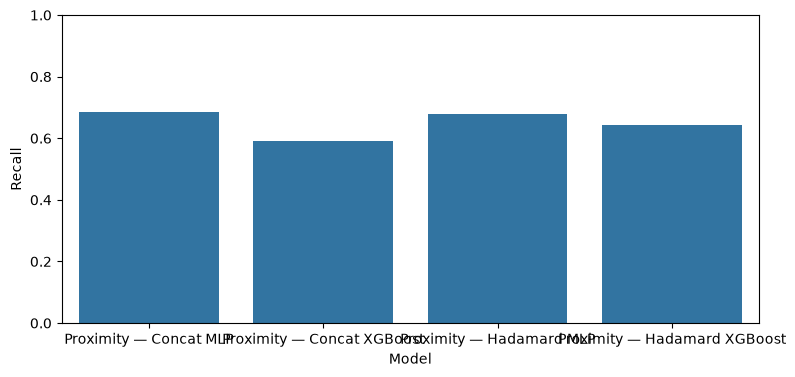

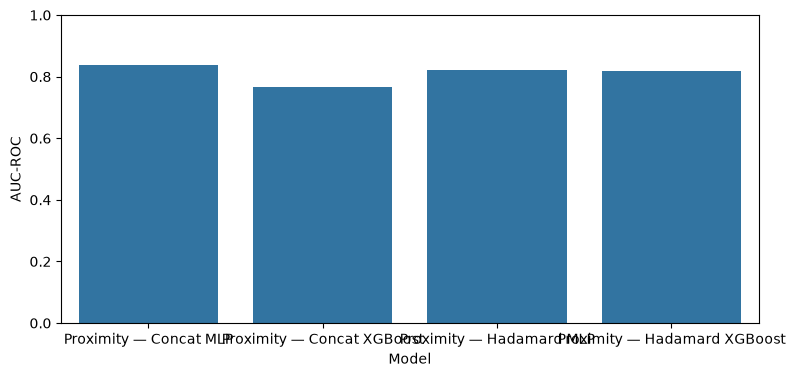

In [267]:
compare_performances_viz(proximity_model_comparison)

# Combined Graph
Use channel attention to learn weights for each embedding 

In [268]:
class FusedNetwork(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        #self.score = nn.Linear(embedding_dim, 1)
        self.score = nn.Sequential(
            nn.Linear(embedding_dim, 64), nn.Tanh(), nn.Linear(64, 1) #nonlinear 
        )

        self.network = nn.Sequential(
            nn.Linear(embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )

    def forward(self, e1, e2, e3, return_weights=False):
        embeddings = torch.stack([e1, e2, e3], dim=1)
        scores = self.score(embeddings)
        weights = torch.softmax(scores, dim=1)
        fused = (weights * embeddings).sum(dim=1)  # batch, embedding_dim
        logits = self.network(fused)
        if return_weights:
            return logits, weights.squeeze(-1)
        return logits

    
    
    
        

In [269]:
# Align identical unordered relationships across all three graph channels.
common_pairs = sorted(
    set(edges) & set(call_edges) & set(proximity_edges)
)

def build_combined_channel_embeddings(node2vec_model, pairs):
    concat_embeddings = []
    product_embeddings = []
    for user_a, user_b in pairs:
        u = node2vec_model.wv[str(user_a)]
        v = node2vec_model.wv[str(user_b)]
        concat_embeddings.append(np.concatenate([u, v]))
        product_embeddings.append(u * v)

    concat_embeddings = np.stack(concat_embeddings).astype(np.float32)
    product_embeddings = np.stack(product_embeddings).astype(np.float32)
    return concat_embeddings, product_embeddings


sms_concat_embeddings, sms_product_embeddings = (
    build_combined_channel_embeddings(sms_node2vec_model, common_pairs)
)
call_concat_embeddings, call_product_embeddings = (
    build_combined_channel_embeddings(call_node2vec_model, common_pairs)
)
proximity_concat_embeddings, proximity_product_embeddings = (
    build_combined_channel_embeddings(proximity_node2vec_model, common_pairs)
)
fused_labels = np.asarray(
    [int(pair in friends_set) for pair in common_pairs],
    dtype=np.float32,
)

print(f"Relationships present in all three graphs: {len(common_pairs):,}")
print(f"Facebook-friend rate: {fused_labels.mean():.2%}")
print(f"Concat shape per channel: {sms_concat_embeddings.shape}")
print(f"Product shape per channel: {sms_product_embeddings.shape}")


Relationships present in all three graphs: 342
Facebook-friend rate: 85.09%
Concat shape per channel: (342, 256)
Product shape per channel: (342, 128)


## Combined attention-model training

In [270]:
# Use identical indices for the SMS, calls, proximity, and target tensors.
all_indices = np.arange(len(fused_labels))
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=fused_labels,
)

sms_train = torch.from_numpy(sms_concat_embeddings[train_indices])
calls_train = torch.from_numpy(call_concat_embeddings[train_indices])
proximity_train = torch.from_numpy(proximity_concat_embeddings[train_indices])
y_fused_train = torch.from_numpy(fused_labels[train_indices]).view(-1, 1)

sms_val = torch.from_numpy(sms_concat_embeddings[val_indices])
calls_val = torch.from_numpy(call_concat_embeddings[val_indices])
proximity_val = torch.from_numpy(proximity_concat_embeddings[val_indices])
y_fused_val = torch.from_numpy(fused_labels[val_indices]).view(-1, 1)
fused_train_weights, fused_minority_class, fused_minority_weight = minority_sample_weights(
    fused_labels[train_indices]
)
fused_val_weights, _, _ = minority_sample_weights(
    fused_labels[val_indices],
    fused_minority_class,
    fused_minority_weight,
)
fused_train_weight_tensor = torch.from_numpy(
    fused_train_weights
).view(-1, 1)
fused_val_weight_tensor = torch.from_numpy(
    fused_val_weights
).view(-1, 1)

fused_train_loader = DataLoader(
    TensorDataset(
        sms_train,
        calls_train,
        proximity_train,
        y_fused_train,
        fused_train_weight_tensor,
    ),
    batch_size=32,
    shuffle=True,
)


fused_model = FusedNetwork(embedding_dim=sms_concat_embeddings.shape[1])
fused_criterion = nn.BCEWithLogitsLoss(reduction='none')
print(
    f'Exploratory combined concat MLP: upweighting class '
    f'{int(fused_minority_class)} by {fused_minority_weight:.2f}x; '
    'no rows removed.'
)
fused_optimizer = torch.optim.Adam(
    fused_model.parameters(), lr=1e-3, weight_decay=1e-4
)

max_epochs = 150
patience = 15
best_val_loss = float('inf')
best_fused_state = None
epochs_without_improvement = 0
fused_train_losses = []
fused_val_losses = []

with tqdm(
    range(max_epochs), desc='Exploratory combined concat MLP', unit='epoch'
) as epoch_progress:
    for epoch in epoch_progress:
        fused_model.train()
        running_loss = 0.0

        for sms_batch, calls_batch, proximity_batch, y_batch, weight_batch in fused_train_loader:
            fused_optimizer.zero_grad()
            logits = fused_model(sms_batch, calls_batch, proximity_batch)
            element_losses = fused_criterion(logits, y_batch)
            loss = (element_losses * weight_batch).mean()
            loss.backward()
            fused_optimizer.step()
            running_loss += loss.item() * y_batch.size(0)

        train_loss = running_loss / len(fused_train_loader.dataset)
        fused_train_losses.append(train_loss)

        fused_model.eval()
        with torch.no_grad():
            val_logits = fused_model(sms_val, calls_val, proximity_val)
            val_element_losses = fused_criterion(val_logits, y_fused_val)
            val_loss = (
                val_element_losses * fused_val_weight_tensor
            ).mean().item()
        fused_val_losses.append(val_loss)
        epoch_progress.set_postfix(
            train_loss=f'{train_loss:.4f}',
            val_loss=f'{val_loss:.4f}',
            best=f'{min(best_val_loss, val_loss):.4f}',
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_fused_state = copy.deepcopy(fused_model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                epoch_progress.set_description(
                    'Exploratory combined concat MLP (early stopped)'
                )
                break

# Evaluate the checkpoint with the lowest validation loss.
fused_model.load_state_dict(best_fused_state)
fused_model.eval()
with torch.no_grad():
    fused_val_logits, validation_attention = fused_model(
        sms_val,
        calls_val,
        proximity_val,
        return_weights=True,
    )
    fused_val_probabilities = torch.sigmoid(
        fused_val_logits.squeeze(1)
    ).numpy()

fused_y_true = y_fused_val.squeeze(1).numpy().astype(int)
fused_y_pred = (fused_val_probabilities >= 0.5).astype(int)
fused_metrics = pd.DataFrame([
    metric_row(
        fused_y_true,
        fused_y_pred,
        fused_val_probabilities,
        'Exploratory combined concat MLP',
    )
]).set_index('Model')
display(fused_metrics.round(4))

mean_attention = validation_attention.mean(dim=0).numpy()
attention_summary = pd.DataFrame(
    {
        'Channel': ['SMS', 'Calls', 'Proximity'],
        'Mean attention weight': mean_attention,
    }
).set_index('Channel')
display(attention_summary.round(4))


Exploratory combined concat MLP: upweighting class 0 by 5.66x; no rows removed.


Exploratory combined concat MLP:   0%|          | 0/150 [00:00<?, ?epoch/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Exploratory combined concat MLP,0.7826,0.9074,0.8305,0.739


,Mean attention weight
Channel,
SMS,0.2128
Calls,0.7361
Proximity,0.0511


# Fresh function-based model comparisons

The original hand-written SMS training loops above are intentionally retained as exploratory work. The cells below initialize fresh models through the shared evaluation functions.

In [271]:
sms_concat_mlp_fresh, sms_concat_mlp_metrics, sms_concat_history_fresh = run_pair_mlp(
    concat_pairs, 'SMS — Concat MLP'
)
sms_concat_xgb_fresh, sms_concat_xgb_metrics = run_pair_xgboost(
    concat_pairs, 'SMS — Concat XGBoost'
)
sms_product_mlp_fresh, sms_product_mlp_metrics, sms_product_history_fresh = run_pair_mlp(
    product_pairs, 'SMS — Hadamard MLP'
)
sms_product_xgb_fresh, sms_product_xgb_metrics = run_pair_xgboost(
    product_pairs, 'SMS — Hadamard XGBoost'
)

sms_model_comparison = pd.DataFrame(
    [
        sms_concat_mlp_metrics,
        sms_concat_xgb_metrics,
        sms_product_mlp_metrics,
        sms_product_xgb_metrics,
    ]
).set_index('Model')
display(sms_model_comparison.round(4))


SMS — Concat MLP: upweighting class 0 by 4.74x; no rows removed.


SMS — Concat MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

SMS — Concat XGBoost: upweighting class 0 by 4.74x; no rows removed.


SMS — Concat XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

SMS — Hadamard MLP: upweighting class 0 by 4.74x; no rows removed.


SMS — Hadamard MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

SMS — Hadamard XGBoost: upweighting class 0 by 4.74x; no rows removed.


SMS — Hadamard XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
SMS — Concat MLP,0.6214,0.8621,0.6466,0.5855
SMS — Concat XGBoost,0.7786,0.8455,0.8966,0.6078
SMS — Hadamard MLP,0.5929,0.8471,0.6207,0.5630
SMS — Hadamard XGBoost,0.8214,0.8583,0.9397,0.6386


In [272]:
# Two independent attention models with separate parameters and input dimensions.
combined_concat_model, combined_concat_metrics, combined_concat_attention, combined_concat_history = run_fused_attention_model(
    sms_concat_embeddings,
    call_concat_embeddings,
    proximity_concat_embeddings,
    fused_labels,
    'Combined — Concat Attention MLP',
)

combined_product_model, combined_product_metrics, combined_product_attention, combined_product_history = run_fused_attention_model(
    sms_product_embeddings,
    call_product_embeddings,
    proximity_product_embeddings,
    fused_labels,
    'Combined — Hadamard Attention MLP',
)

combined_model_comparison = pd.DataFrame(
    [combined_concat_metrics, combined_product_metrics]
).set_index('Model')
combined_attention_comparison = pd.concat(
    [combined_concat_attention, combined_product_attention],
    ignore_index=True,
)
display(combined_model_comparison.round(4))
display(combined_attention_comparison.round(4))


Combined — Concat Attention MLP: upweighting class 0 by 5.66x; no rows removed.


Combined — Concat Attention MLP:   0%|          | 0/150 [00:00<?, ?epoch/s]

Combined — Hadamard Attention MLP: upweighting class 0 by 5.66x; no rows removed.


Combined — Hadamard Attention MLP:   0%|          | 0/150 [00:00<?, ?epoch/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Combined — Concat Attention MLP,0.7536,0.8889,0.8136,0.6407
Combined — Hadamard Attention MLP,0.6957,0.8958,0.7288,0.7136


,Model,Channel,Mean attention weight
0,Combined — Concat Attention MLP,SMS,0.5671
1,Combined — Concat Attention MLP,Calls,0.3491
2,Combined — Concat Attention MLP,Proximity,0.0838
3,Combined — Hadamard Attention MLP,SMS,0.5825
4,Combined — Hadamard Attention MLP,Calls,0.3773
5,Combined — Hadamard Attention MLP,Proximity,0.0402


## Final model comparison

In [273]:
def results_with_group(results, dataset):
    grouped = results.reset_index().copy()
    grouped.insert(0, 'Dataset', dataset)
    return grouped


all_model_results = pd.concat(
    [
        results_with_group(sms_model_comparison, 'SMS'),
        results_with_group(call_model_comparison, 'Calls'),
        results_with_group(proximity_model_comparison, 'Proximity'),
        results_with_group(combined_model_comparison, 'Combined'),
    ],
    ignore_index=True,
)

model_results_table = (
    great_tables.GT(
        all_model_results,
        rowname_col='Model',
        groupname_col='Dataset',
    )
    .tab_header(
        title=great_tables.md('**Facebook-Friend Prediction Results**'),
        subtitle='Fresh, stratified validation evaluations with minority-class upweighting',
    )
    .tab_stubhead(label='Model')
    .cols_label(
        Accuracy='Accuracy',
        Precision='Precision',
        Recall='Recall',
        **{'AUC-ROC': 'ROC AUC'},
    )
    .fmt_number(
        columns=['Accuracy', 'Precision', 'Recall', 'AUC-ROC'],
        decimals=3,
    )
    .data_color(
        columns=['Accuracy', 'Precision', 'Recall', 'AUC-ROC'],
        palette=['#f1f5f9', '#bfdbfe', '#2563eb'],
        domain=[0, 1],
    )
    .tab_source_note(
        great_tables.md(
            'ROC AUC uses probabilities. MLP checkpoints use the lowest weighted validation loss; no observations are downsampled.'
        )
    )
    .tab_options(
        table_width='100%',
        table_font_names=['Inter', 'Arial', 'sans-serif'],
        heading_background_color='#0f172a',
        heading_title_font_size='22px',
        heading_title_font_weight='700',
        heading_subtitle_font_size='13px',
        column_labels_background_color='#dbeafe',
        column_labels_font_weight='700',
        row_group_background_color='#eff6ff',
        row_group_font_weight='700',
        stub_background_color='#f8fafc',
        data_row_padding='8px',
        row_striping_include_table_body=True,
        row_striping_background_color='#f8fafc',
    )
)

model_results_table


GT(_tbl_data=      Dataset                              Model  Accuracy  Precision  \
0         SMS                   SMS — Concat MLP  0.621429   0.862069   
1         SMS               SMS — Concat XGBoost  0.778571   0.845528   
2         SMS                 SMS — Hadamard MLP  0.592857   0.847059   
3         SMS             SMS — Hadamard XGBoost  0.821429   0.858268   
4       Calls                 Calls — Concat MLP  0.771930   0.935065   
5       Calls             Calls — Concat XGBoost  0.815789   0.882979   
6       Calls               Calls — Hadamard MLP  0.780702   0.935897   
7       Calls           Calls — Hadamard XGBoost  0.885965   0.892157   
8   Proximity             Proximity — Concat MLP  0.815963   0.261029   
9   Proximity         Proximity — Concat XGBoost  0.781329   0.206478   
10  Proximity           Proximity — Hadamard MLP  0.800693   0.242946   
11  Proximity       Proximity — Hadamard XGBoost  0.815806   0.252847   
12   Combined    Combined — Concat Attention MLP  0.753623   0.888889   
13   Combined  Combined — Hadamard Attention MLP  0.695652   0.895833   

      Recall   AUC-ROC  
0   0.646552  0.585489  
1   0.896552  0.607759  
2   0.620690  0.563039  
3   0.939655  0.638649  
4   0.774194  0.833077  
5   0.892473  0.790579  
6   0.784946  0.835125  
7   0.978495  0.842806  
8   0.684008  0.839263  
9   0.589595  0.766581  
10  0.680154  0.820891  
11  0.641618  0.817979  
12  0.813559  0.640678  
13  0.728814  0.713559  , _body=<great_tables._gt_data.Body object at 0x33aef7e00>, _boxhead=Boxhead([ColInfo(var='Dataset', type=<ColInfoTypeEnum.row_group: 3>, column_label='Dataset', column_align='left', column_width=None), ColInfo(var='Model', type=<ColInfoTypeEnum.stub: 2>, column_label='Model', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='AUC-ROC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC AUC', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3346df5f0>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Facebook-Friend Prediction Results**'), subtitle='Fresh, stratified validation evaluations with minority-class upweighting', preheader=None), _stubhead='Model', _summary_rows=<great_tables._gt_data.SummaryRows object at 0x33b2d0cb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x33687b5c0>, _source_notes=[Md(text='ROC AUC uses probabilities. MLP checkpoints use the lowest weighted validation loss; no observations are downsampled.')], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Accuracy', rows=[0], mask=None), grpname=None, colname='Accuracy', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#9abef9')]), StyleInfo(locname=LocBody(columns='Accuracy', rows=[1], mask=None), grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#6998f3')]), StyleInfo(locname=LocBody(columns='Accuracy', rows=[2], mask=None), grpname=None, colname='Accuracy', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a2c5fa')]), StyleInfo(locname=LocBody(columns='Accuracy', rows=[3], mask=None), grpname=None, colname='Accu